<a href="https://colab.research.google.com/github/yandri918/belajar_machine_learning_buku_ONNO-W-Purba/blob/1April2026/Studi_kasus_segmentasi_pelanggan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [2]:
print("=" * 80)
print("BAB 23 - UNSUPERVISED LEARNING I: CLUSTERING")
print("=" * 80)

BAB 23 - UNSUPERVISED LEARNING I: CLUSTERING


In [3]:
# 1. Load data
df = pd.read_csv("segmentasi_pelanggan.csv")

In [4]:
print("\n[1] DATA AWAL")
print(df)


[1] DATA AWAL
   pelanggan  pendapatan_tahunan  skor_belanja
0         P1                  15            39
1         P2                  16            81
2         P3                  17             6
3         P4                  18            77
4         P5                  35            40
5         P6                  36            76
6         P7                  37             6
7         P8                  38            72
8         P9                  60            55
9        P10                  62            52
10       P11                  64            59
11       P12                  66            54
12       P13                  90            20
13       P14                  92            18
14       P15                  94            22
15       P16                  96            19


In [5]:
# 2. Pilih fitur
X = df[["pendapatan_tahunan", "skor_belanja"]]

In [6]:
# 3. Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
# 4. Coba beberapa nilai k
print("\n[2] SILHOUETTE SCORE UNTUK BEBERAPA K")
for k in range(2, 6):
  model = KMeans(n_clusters=k, random_state=42, n_init=10)
  labels = model.fit_predict(X_scaled)
  score = silhouette_score(X_scaled, labels)
  print(f"k={k}, silhouette_score={score:.4f}")


[2] SILHOUETTE SCORE UNTUK BEBERAPA K
k=2, silhouette_score=0.4717
k=3, silhouette_score=0.5591
k=4, silhouette_score=0.6735
k=5, silhouette_score=0.7133


In [8]:
# 5. Final model
k_final = 3
model = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df["cluster"] = model.fit_predict(X_scaled)

In [9]:
print("\n[3] HASIL CLUSTER")
print(df)


[3] HASIL CLUSTER
   pelanggan  pendapatan_tahunan  skor_belanja  cluster
0         P1                  15            39        1
1         P2                  16            81        0
2         P3                  17             6        1
3         P4                  18            77        0
4         P5                  35            40        1
5         P6                  36            76        0
6         P7                  37             6        1
7         P8                  38            72        0
8         P9                  60            55        0
9        P10                  62            52        0
10       P11                  64            59        0
11       P12                  66            54        0
12       P13                  90            20        2
13       P14                  92            18        2
14       P15                  94            22        2
15       P16                  96            19        2


In [10]:
# 6. Ringkasan cluster
ringkasan = df.groupby("cluster")[["pendapatan_tahunan", "skor_belanja"]].mean()
print("\n[4] RATA-RATA TIAP CLUSTER")
print(ringkasan)


[4] RATA-RATA TIAP CLUSTER
         pendapatan_tahunan  skor_belanja
cluster                                  
0                      45.0         65.75
1                      26.0         22.75
2                      93.0         19.75


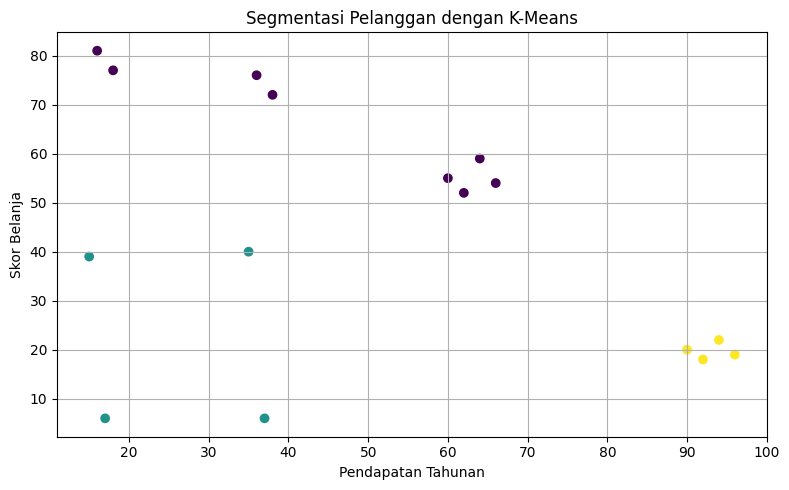

In [11]:
# 7. Visualisasi
plt.figure(figsize=(8, 5))
plt.scatter(df["pendapatan_tahunan"], df["skor_belanja"], c=df["cluster"])
plt.xlabel("Pendapatan Tahunan")
plt.ylabel("Skor Belanja")
plt.title("Segmentasi Pelanggan dengan K-Means")
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
print("\n[5] INSIGHT AWAL")
print("- Cluster yang berbeda menunjukkan pola pelanggan yang berbeda.")
print("- Ada kelompok pelanggan dengan pendapatan tinggi tetapi skor belanja rendah.")
print("- Ada juga kelompok pelanggan dengan pendapatan menengah/tinggi dan skor belanja lebih aktif.")
print("- Hasil ini bisa dipakai sebagai dasar strategi pemasaran yang lebih terarah.")


[5] INSIGHT AWAL
- Cluster yang berbeda menunjukkan pola pelanggan yang berbeda.
- Ada kelompok pelanggan dengan pendapatan tinggi tetapi skor belanja rendah.
- Ada juga kelompok pelanggan dengan pendapatan menengah/tinggi dan skor belanja lebih aktif.
- Hasil ini bisa dipakai sebagai dasar strategi pemasaran yang lebih terarah.


In [13]:
print("\nSELESAI. Anda sudah menjalankan studi kasus segmentasi pelanggan.")
print("=" * 80)


SELESAI. Anda sudah menjalankan studi kasus segmentasi pelanggan.
